In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_csv("../../data/raw/olist_orders_dataset.csv")

In [4]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [5]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
orders["order_id"].nunique()

99441

In [7]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [8]:
orders["customer_id"].duplicated().sum()

np.int64(0)

In [11]:
order_status = orders["order_status"].value_counts()
order_status

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

<Axes: xlabel='order_status'>

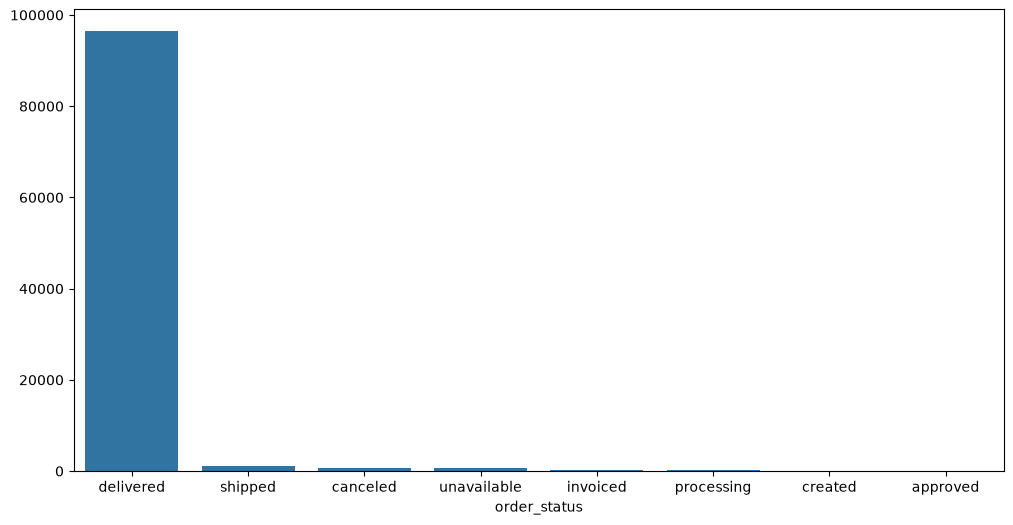

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(x=order_status.index,
            y=order_status.values)

In [15]:
orders["order_status"].value_counts(normalize=True)*100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [21]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [22]:
orders["order_purchase_timestamp"].dt.to_period("Y").value_counts()

order_purchase_timestamp
2018    54011
2017    45101
2016      329
Freq: Y-DEC, Name: count, dtype: int64

In [27]:
order_per_year = (orders.groupby(orders["order_purchase_timestamp"].dt.to_period("Y")).size())

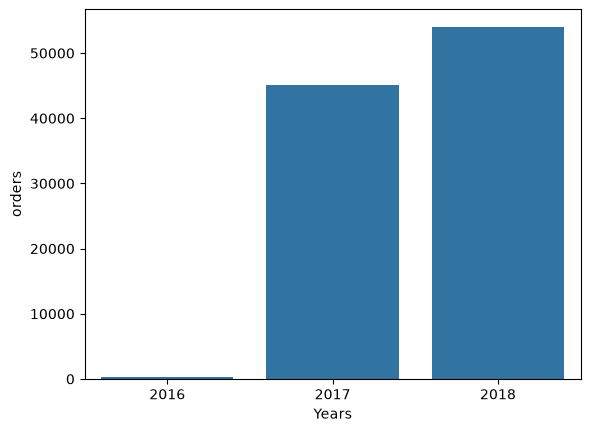

In [37]:
sns.barplot(
    x=order_per_year.index.astype(str),
    y=order_per_year.values
)
plt.xlabel("Years")
plt.ylabel("orders")
plt.savefig("../../output/charts/orders/order_per_year_barplot",dpi=300)
plt.show()

In [29]:
order_per_month = (orders.groupby(orders["order_purchase_timestamp"].dt.to_period("M")).size())

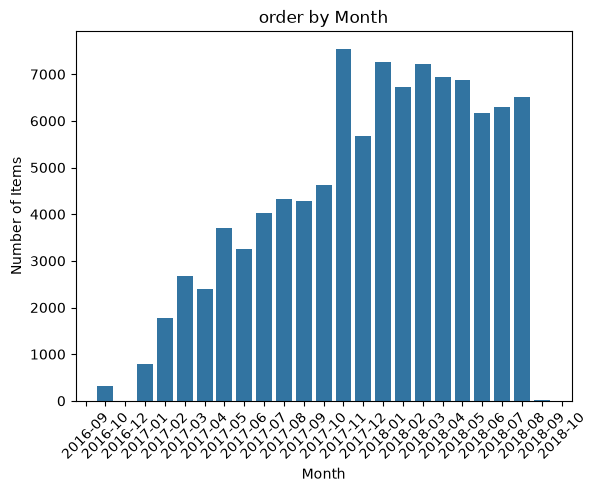

In [35]:
sns.barplot(
    x=order_per_month.index.astype(str),
    y=order_per_month.values
)
plt.xticks(rotation=45)
plt.title("order by Month")
plt.xlabel("Month")
plt.ylabel("Number of Items")
plt.savefig("../../output/charts/orders/order_by_month_barplot",dpi=300)
plt.show()

In [44]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

delivered_orders = orders[orders["order_status"] == "delivered"].copy()
delivered_orders["delivery_time_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

delivered_orders["delivery_time_days"].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

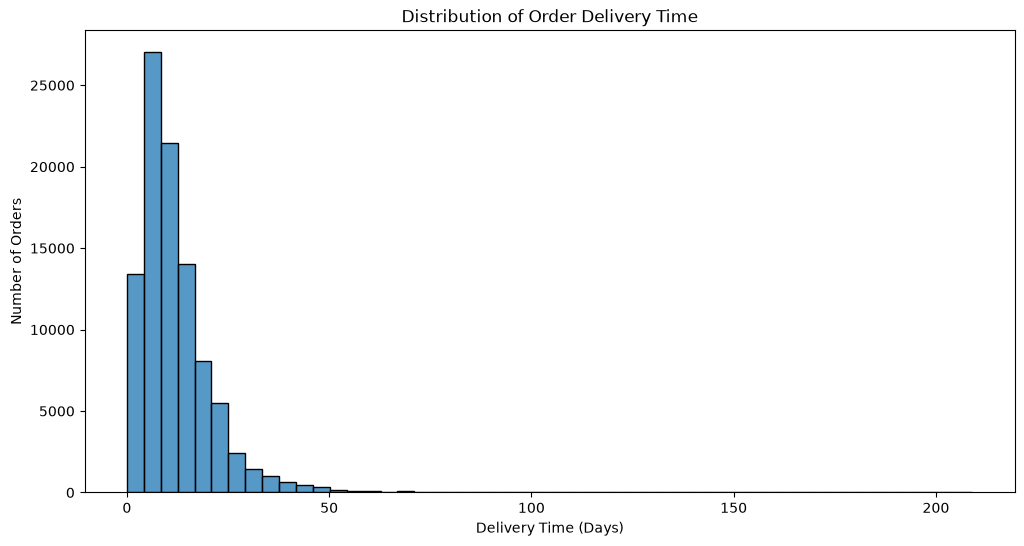

In [45]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=delivered_orders,
    x="delivery_time_days",
    bins=50
)
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Order Delivery Time")
plt.savefig("../../output/charts/orders/delivery_time_distribution.png", dpi=300)
plt.show()

In [42]:
orders["purchase_day"] = orders["order_purchase_timestamp"].dt.day_name()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
orders_per_weekday = orders["purchase_day"].value_counts().reindex(weekday_order)
orders_per_weekday

purchase_day
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64

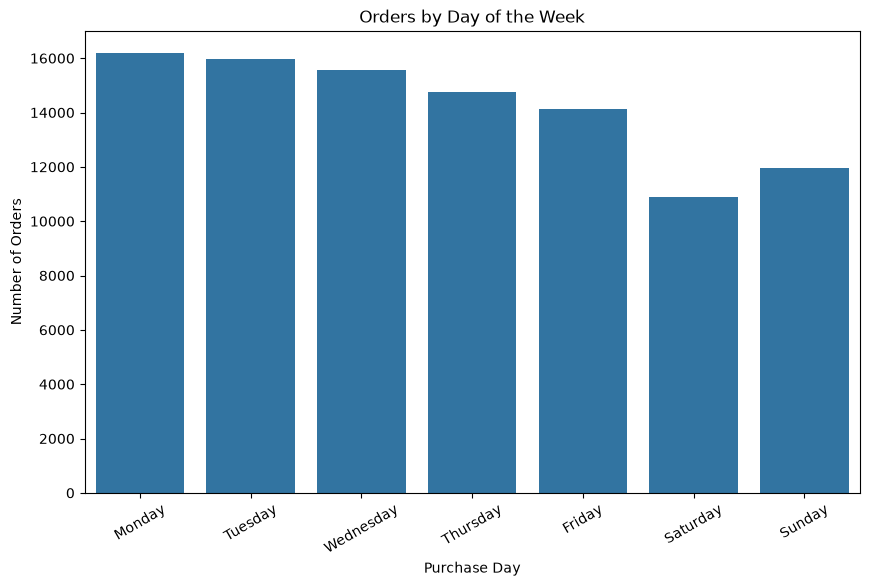

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=orders_per_weekday.index,
    y=orders_per_weekday.values
)
plt.xticks(rotation=30)
plt.xlabel("Purchase Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of the Week")
plt.savefig("../../output/charts/orders/orders_by_weekday.png", dpi=300)
plt.show()

In [47]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

In [48]:
orders[date_cols].info()
orders[date_cols].isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[us]
 1   order_approved_at              99281 non-null  datetime64[us]
 2   order_delivered_carrier_date   97658 non-null  datetime64[us]
 3   order_delivered_customer_date  96476 non-null  datetime64[us]
 4   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5)
memory usage: 3.8 MB


order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [49]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["purchase_day"] = orders["order_purchase_timestamp"].dt.day_name()
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

In [50]:
orders["approval_time_hours"] = (
    orders["order_approved_at"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600

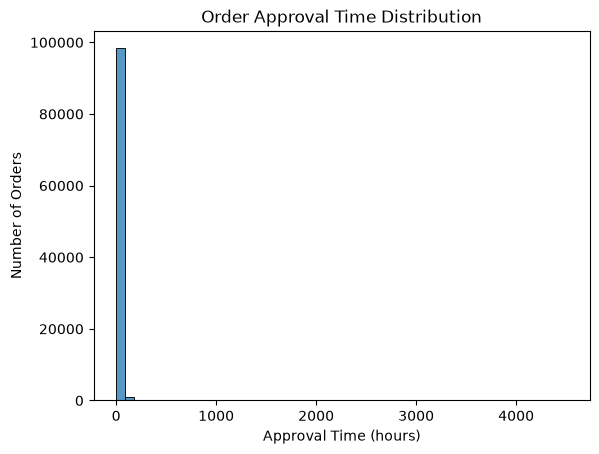

In [63]:
sns.histplot(
    data=orders,
    x="approval_time_hours",
    bins=50
)

plt.xlabel("Approval Time (hours)")
plt.ylabel("Number of Orders")
plt.title("Order Approval Time Distribution")
plt.savefig("../../output/charts/orders/order_approval_time",dpi=300)
plt.show()

In [53]:
orders["delivery_difference_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (60 * 60 * 24)

In [55]:
import numpy as np
orders["delivery_status"] = np.where(
    orders["delivery_difference_days"] < 0,
    "Early",
    np.where(
        orders["delivery_difference_days"] > 0,
        "Late",
        "On Time"
    )
)

In [ ]:
delivery_status = orders["delivery_status"].value_counts()

delivery_status
Early      88649
Late        7827
On Time     2965
Name: count, dtype: int64

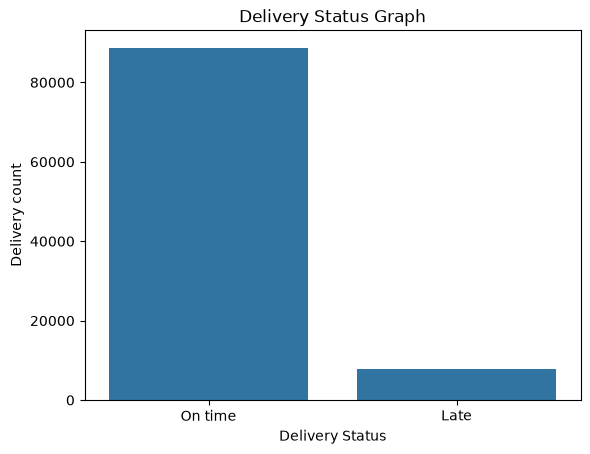

In [61]:
sns.barplot(
    x=delivery_status.index,
    y=delivery_status.values
)
plt.xlabel("Delivery Status")
plt.ylabel("Delivery count")
plt.title("Delivery Status Graph")
plt.savefig("../../output/charts/orders/delivery_status",dpi=300)
plt.show()

In [62]:
orders.groupby("purchase_year")["delivery_difference_days"].mean()

purchase_year
2016   -35.739233
2017   -11.650857
2018   -10.664398
Name: delivery_difference_days, dtype: float64

## Key Observations

### 1. Order Data Overview

- The dataset contains **99,441 unique orders**.
- There are **no duplicate order IDs**, so each row represents one order.
- The `customer_id` column also has no duplicate values, which indicates that each customer placed one order in this dataset.

### 2. Order Status

- **Delivered** is the most common order status, with **96,478 orders**.
- The remaining orders are distributed among statuses such as **shipped, canceled, unavailable, invoiced, processing, created, and approved**.
- This shows that most orders in the dataset were completed successfully.

### 3. Missing Values

- Most columns do not contain missing values.
- Some orders do not have approval, carrier delivery, or customer delivery dates.
- These missing dates are expected because some orders were canceled, unavailable, or had not reached that stage of delivery.

### 4. Orders by Year

- The dataset mainly contains orders from **2017 and 2018**.
- **2018** had the highest number of orders, followed by **2017**.
- Only a small number of orders were recorded in **2016**, so the main business activity is concentrated in 2017 and 2018.

### 5. Orders by Month

- The monthly chart shows how order activity changed over time.
- Order volume was generally higher during 2017 and 2018 than in 2016.
- Studying monthly order counts can help identify periods of high demand and possible seasonal patterns.

### 6. Delivery Time

- Delivery time was calculated only for orders with the status **delivered**.
- The average delivery time was approximately **12 days**.
- Half of the delivered orders took **10 days or less**, while 75% took **15 days or less**.
- Most orders were delivered within a relatively short period, although a small number took much longer.

### 7. Orders by Day of the Week

- **Monday** was the busiest day for placing orders.
- **Saturday** had the lowest number of orders, followed by Sunday.
- Customers placed more orders during the weekdays than during the weekend.

### Overall Insight

Overall, the dataset contains a large number of mostly completed orders, with the highest activity occurring in 2017 and 2018. Customers generally received their orders in about 12 days, and order activity was higher during weekdays, especially on Monday. The missing delivery dates are mainly related to orders that were not completed or delivered.